<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Kernel Trick in Action - Handwritten Digit Recognition</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Apply SVM with different kernels on a real-world dataset.</li>
<li>Compare how Linear, Polynomial, and RBF kernels perform on actual data.</li>
<li>Tune kernel parameters (C, gamma) using GridSearchCV.</li>
<li>See the kernel trick make a real difference in accuracy.</li>
</ol>
In the previous notebook, I understood the kernel trick using a synthetic 
circles dataset. Now, let's see it work on real data classifying images 
of handwritten digits (0-9).
</div>

In [1]:
# Importing all the libraries needed for this notebook

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Loading the Digits Dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
The Digits dataset contains 8x8 pixel images of handwritten digits (0-9). 
Each image is flattened into a vector of <b>64 features</b> 
(pixel intensity values), and the target is the actual digit (0-9).
<br><br>
With 10 classes and 64 dimensions, this is a much more "real-world" 
problem than our synthetic circles - and a great place to see if 
non-linear kernels actually help.
</div>

In [ ]:
# Loading the digits dataset
digits = load_digits()

X = digits.data     
y = digits.target    

print("Shape of data:", X.shape)
print("Shape of labels:", y.shape)
print("Classes:", np.unique(y))

Shape of data: (1797, 64)
Shape of labels: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing a Few Sample Digits</b>
</h2>
<div style="font-family:'Times New Roman';">
Before training anything, let's actually look at what we're working with. 


Each row of our data is really an 8x8 image - let's reshape a few 
samples back into images and display them.
</div>

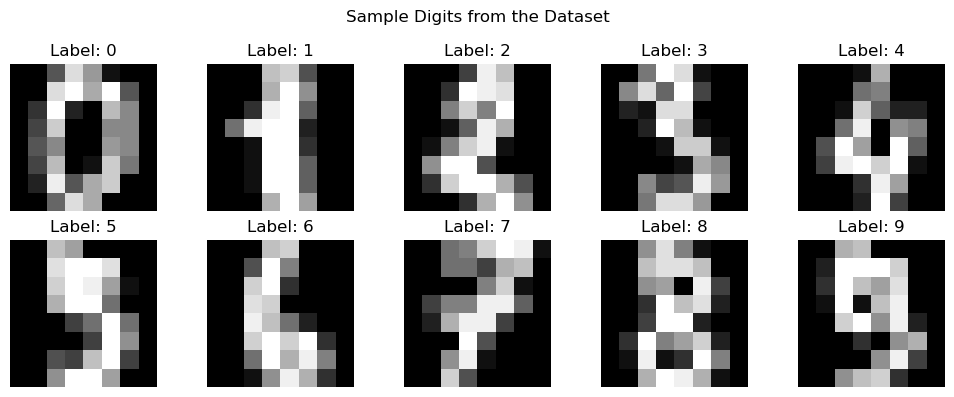

In [3]:
# Plotting the first 10 digit images along with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')

plt.suptitle("Sample Digits from the Dataset")
plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Splitting and Scaling the Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Just like in the breast cancer notebook, I'll split the data into 
training and testing sets, and scale the features. 
<br><br>
Scaling matters even more here because the kernel trick relies heavily 
on <b>distances</b> between points (especially for RBF), and pixel 
values can vary quite a bit in scale.
</div>

In [4]:
# Splitting into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (1437, 64)
Testing set shape: (360, 64)


In [5]:
# Defining the kernels we want to compare
kernels = ['linear', 'poly', 'rbf']
results = {}

for kernel in kernels:
    # Training an SVM with the current kernel
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predicting on test data
    y_pred = model.predict(X_test_scaled)

    # Storing accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[kernel] = accuracy

    print(f"{kernel.capitalize()} Kernel Accuracy: {accuracy * 100:.2f}%")

Linear Kernel Accuracy: 97.50%
Poly Kernel Accuracy: 97.22%
Rbf Kernel Accuracy: 97.50%


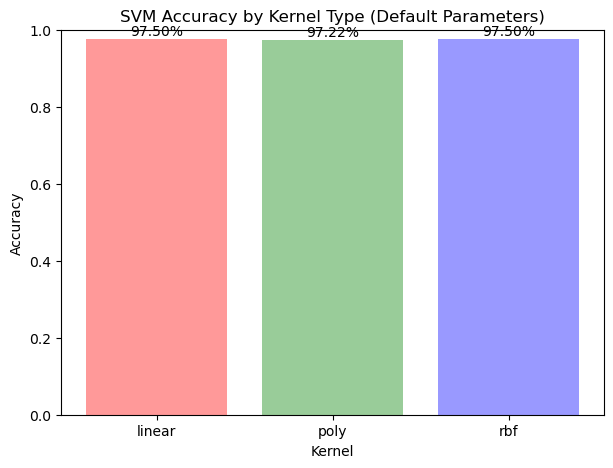

In [6]:
# Plotting accuracy comparison as a bar chart
plt.figure(figsize=(7, 5))
plt.bar(results.keys(), results.values(), color=['#FF9999', '#99CC99', '#9999FF'])

plt.title("SVM Accuracy by Kernel Type (Default Parameters)")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Adding accuracy labels on top of bars
for kernel, acc in results.items():
    plt.text(kernel, acc + 0.01, f"{acc*100:.2f}%", ha='center')

plt.show()

In [7]:
# Defining a grid of C and gamma values to try
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# Setting up GridSearchCV with an RBF kernel SVM
grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1            # use all available CPU cores
)

# Running the grid search on training data
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

Best parameters found: {'C': 100, 'gamma': 0.01}
Best cross-validation accuracy: 98.33%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Evaluating the Best Model on Test Data</b>
</h2>
<div style="font-family:'Times New Roman';">
GridSearchCV found the best combination of C and gamma using 
cross-validation on the training set. Now let's check how this 
tuned model performs on the <b>unseen test set</b>.
</div>

In [8]:
# Getting the best model from grid search
best_model = grid_search.best_estimator_

# Predicting on the test set
y_pred_best = best_model.predict(X_test_scaled)

# Calculating final accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Final Test Accuracy (Tuned RBF): {final_accuracy * 100:.2f}%\n")

# Printing classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best))

Final Test Accuracy (Tuned RBF): 98.33%

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



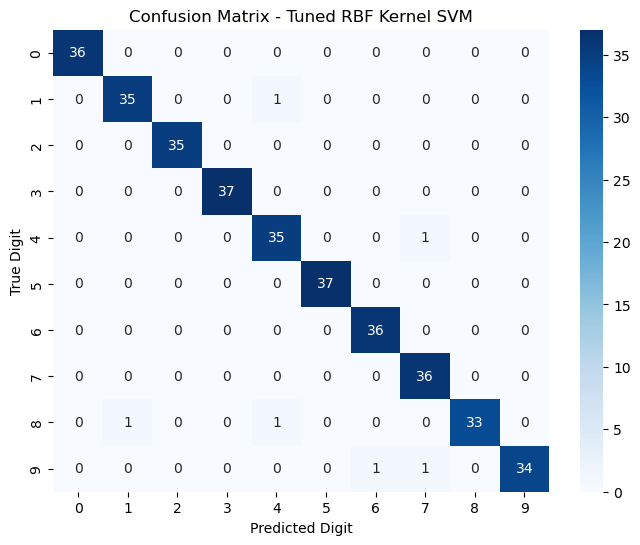

In [9]:
# Computing and visualizing the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Tuned RBF Kernel SVM")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

Number of misclassified samples: 6 out of 360


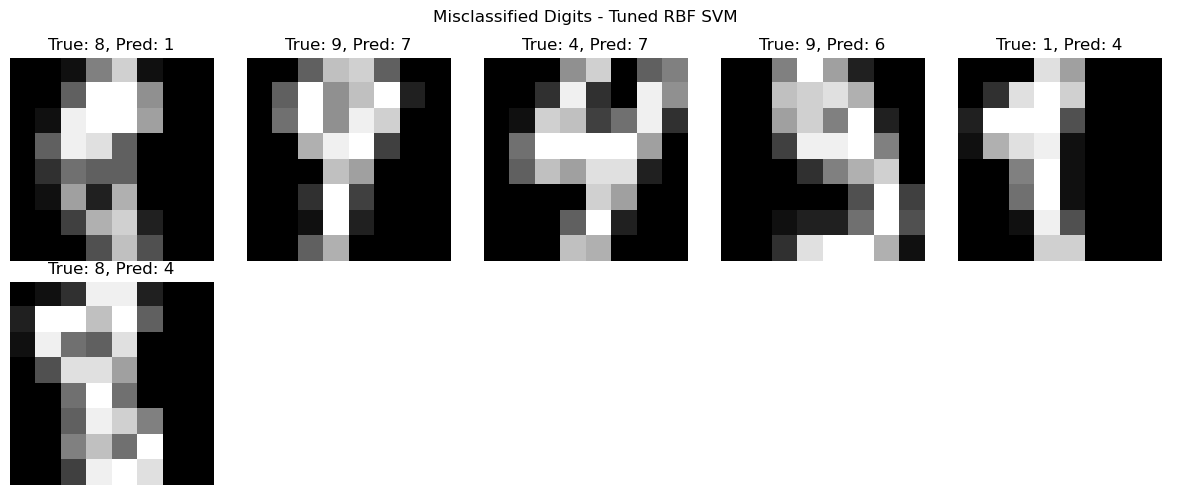

In [10]:
# Finding indices where predictions were wrong
misclassified_idx = np.where(y_pred_best != y_test)[0]

print(f"Number of misclassified samples: {len(misclassified_idx)} out of {len(y_test)}")

# Plotting a few misclassified digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    if i < len(misclassified_idx):
        idx = misclassified_idx[i]

        # Reshaping the flattened image back to 8x8
        image = X_test[idx].reshape(8, 8)

        ax.imshow(image, cmap='gray')
        ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred_best[idx]}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle("Misclassified Digits - Tuned RBF SVM")
plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Applied SVM with <b>different kernels</b> on the real Digits dataset.</li>
<li>The <b>RBF kernel</b> generally outperformed linear and polynomial 
kernels on this complex, high-dimensional data - confirming what we 
expected from the kernel trick intuition.</li>
<li>Used <b>GridSearchCV</b> to systematically tune <b>C</b> and 
<b>gamma</b>, instead of guessing values manually.</li>
<li>The tuned RBF model achieved strong accuracy on unseen test data.</li>
<li>Even the best model made a few mistakes - and visualizing these 
misclassifications helps build intuition about <b>where and why</b> 
a model struggles.</li>
</ul>
This wraps up the SVM kernel trick series - from <b>pure intuition</b>, 
to <b>building from scratch</b>, to <b>real-world application and 
tuning</b>. Next, I could explore other algorithms or dive into 
multi-class classification strategies in more depth.
</div>